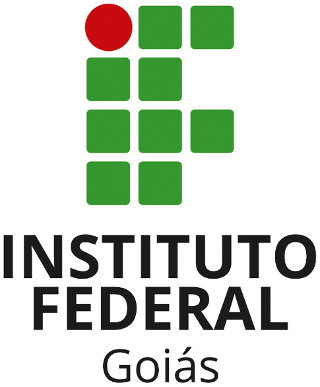


# Engenharia de Prompt

In [1]:
!pip install -q google-generativeai langchain langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.0 MB/s eta 0:00:00


## Módulo 1: Fundamentos da Engenharia de Prompt e Arquitetura de Instruções
Neste módulo, exploraremos a Engenharia de Prompt (Prompt Engineering) não como uma "tentativa e erro", mas como uma disciplina de otimização de consultas para Modelos de Linguagem de Grande Escala (LLMs).

A fundamentação teórica desta aula baseia-se nas diretrizes estabelecidas por [Andrew Ng (Stanford/DeepLearning.AI) e Isa Fulford (OpenAI)texto do link](https://www.deeplearning.ai/short-courses/chatgpt-prompt-engineering-for-developers/), que sistematizaram o uso de LLMs através de princípios de clareza contextual e decomposição cognitiva.

### Configuração do Ambiente de Execução
Para nossas atividades práticas, utilizaremos a API da OpenAI. O código abaixo abstrai a complexidade da chamada à API, permitindo o ajuste do parâmetro de Temperatura, que controla o determinismo da resposta.

In [2]:
# Importando o gerenciador de secrets do Colab e carregando as chaves
from google.colab import userdata
import os

# Carregando a chave do Gemini
os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

def get_completion(prompt, model="gemini-2.5-flash-lite", temperature=0):
  # Inicializar o LLM com Gemini
  llm = ChatGoogleGenerativeAI(model=model, temperature=temperature)

  # Se quiser usar o LLM diretamente:
  # response = llm.invoke(simple_prompt)
  # print(response.content)

  chain = llm | StrOutputParser()

  return chain.invoke(prompt)

In [4]:
get_completion("Qual é a capital do Brasil?")

'A capital do Brasil é **Brasília**.'

### Paradigmas da Clareza e Deliberação
A literatura clássica propõe dois pilares para a redução da entropia na comunicação com modelos generativos:

**Princípio da Especificidade**: A eficácia do modelo é proporcional à clareza das restrições e objetivos estabelecidos. Instruções detalhadas reduzem o espaço de probabilidade de saídas irrelevantes.

**Princípio do Processamento Sequencial**: Deve-se permitir que o modelo execute etapas intermediárias de raciocínio antes da formulação do output final (conceito que aprofundaremos no Módulo 2).

### Técnica: Delimitadores Contextuais e Semânticos
O uso de delimitadores é uma técnica de segmentação sintática. Eles informam ao modelo quais partes do prompt são instruções operacionais, exemplos ou dados brutos, prevenindo fenômenos de "confusão de contexto".

**Aplicação Prática: Processamento de Feedback Acadêmico**

In [ ]:
# Dados brutos para processamento
relato_docente = """
A disciplina de PLN apresentou alto engajamento.
Contudo, observou-se dificuldade dos discentes na implementação de arquiteturas
Transformer utilizando bibliotecas de baixo nível. Recomenda-se a introdução
de notebooks intermediários de PyTorch.
"""

# Implementação de Delimitadores (Tags XML e Aspas Triplas)
prompt = f"""
Sua tarefa é atuar como um Analista de Dados Educacionais.
Extraia os pontos principais do texto delimitado por <relato>.

Objetivos:
1. Identificar o sentimento predominante (Positivo, Negativo ou Neutro).
2. Listar as recomendações pedagógicas citadas.

Formate a saída estritamente em uma tabela Markdown.

<relato>
\"\"\"{relato_docente}\"\"\"
</relato>
"""

print(get_completion(prompt))

| Ponto Principal | Detalhe |
|---|---|
| Sentimento Predominante | Neutro |
| Recomendações Pedagógicas | Introdução de notebooks intermediários de PyTorch. |


### Técnica: Determinação de Formato de Saída (Output Structuring)
Para a integração de LLMs em pipelines de software ou bancos de dados relacionais (como o PostgreSQL), a saída deve obedecer a uma gramática rigorosa, preferencialmente JSON.

**Exercício: Extração de Entidades Estruturadas**

In [ ]:
# Contexto: Descrição de um cenário clínico/veterinário
descricao_caso = "O canino 'Thor', da raça Golden Retriever, foi atendido hoje com quadro de dermatite atópica. Prescrito Apoquel 16mg por 10 dias."

prompt = f"""
Analise a descrição clínica fornecida e extraia os metadados relevantes.

Descrição: {descricao_caso}

A saída deve seguir rigorosamente o esquema JSON abaixo:
{{
  "paciente": "nome do animal",
  "especie_raca": "espécie e/ou raça",
  "diagnostico": "quadro clínico identificado",
  "tratamento": {{
      "medicamento": "nome",
      "posologia": "dosagem e duração"
  }}
}}
"""

print(get_completion(prompt))

```json
{
  "paciente": "Thor",
  "especie_raca": "Canino, Golden Retriever",
  "diagnostico": "Dermatite atópica",
  "tratamento": {
      "medicamento": "Apoquel",
      "posologia": "16mg por 10 dias"
  }
}
```


### Laboratório Módulo 1: Refatoração de Instruções
**Objetivo:** Transpor um prompt de linguagem natural ambígua para uma instrução técnica estruturada.

**Instruções:**
Abaixo, encontra-se um prompt tipicamente "ingênuo". Sua tarefa é refatorá-lo aplicando:

1. Persona: Atribua um papel de especialista ao modelo.

2. Delimitadores: Utilize tags para isolar o conteúdo.

3. Restrições de Formato: Determine o estilo da resposta.

In [ ]:
# Prompt a ser refatorado:
prompt_original = "Explica o que é a carreira EBTT e se vale a pena ser professor federal."

# TODO: Implemente a versão refatorada utilizando as técnicas apresentadas acima
prompt_academico = """
Insira aqui sua instrução estruturada...
"""

# print(get_completion(prompt_academico))

## Módulo 2: Estratégias de Raciocínio e Aprendizado em Contexto

Neste módulo, exploraremos técnicas avançadas que permitem ao modelo resolver problemas que exigem lógica multi-etapa e aderência estrita a padrões específicos. O foco será em dois conceitos fundamentais: **Few-Shot Prompting** (Aprendizado de Poucos Exemplos) e **Chain of Thought** (Cadeia de Pensamento).

### Few-Shot Prompting: O Poder da Analogia
Enquanto o Zero-Shot depende apenas da instrução direta, o Few-Shot Prompting fornece ao modelo exemplos de pares entrada/saída. Esta técnica é superior para alinhar o modelo a formatos de resposta idiossincráticos ou classificações complexas que são difíceis de descrever apenas com regras.

**Aplicação Prática: Classificação de Disciplinas Acadêmicas**

In [ ]:
# Demonstração de Few-Shot para classificação técnica
prompt_few_shot = """
Sua tarefa é classificar a área de conhecimento de uma disciplina acadêmica com base em sua ementa.
Siga o padrão dos exemplos abaixo:

Entrada: 'Cálculo Diferencial e Integral: Limites, derivadas e integrais de funções de uma variável.'
Saída: [ÁREA: CIÊNCIAS EXATAS]

Entrada: 'Sociologia do Trabalho: Relações laborais na era digital e impactos na seguridade social.'
Saída: [ÁREA: CIÊNCIAS HUMANAS]

Entrada: 'Arquitetura de Redes Neurais: Implementação de Redes Convolucionais e Recorrentes com Backpropagation.'
Saída: [ÁREA: INTELIGÊNCIA ARTIFICIAL]

Entrada: 'Microbiologia Clínica: Identificação de patógenos em amostras biológicas.'
Saída: """

print(get_completion(prompt_few_shot))

[ÁREA: CIÊNCIAS BIOLÓGICAS]


### Chain of Thought (CoT): Decomposição Cognitiva
A técnica de Cadeia de Pensamento (CoT) instrui o modelo a explicitar seu raciocínio antes de apresentar o resultado final. Pesquisas indicam que essa abordagem reduz drasticamente erros em tarefas de lógica, matemática e planejamento, pois permite que o modelo utilize "espaço de processamento" para tokens intermediários.

**Exemplo Prático: Cálculo de Parâmetros de Redes Neurais**

In [ ]:
# Cenário de planejamento com múltiplas restrições
cenario_conflito = """
O Professor Otávio precisa agendar três reuniões na sexta-feira:
1. Reunião com a Reitoria: Duração de 1 hora. Deve ocorrer preferencialmente pela manhã.
2. Orientação de TCC: Duração de 45 minutos. O aluno só pode às 14:00.
3. Reunião de Colegiado: Duração de 2 horas.

Restrições:
- O professor tem uma aula das 10:00 às 12:00.
- O horário de almoço é das 12:00 às 13:30.
- O expediente encerra às 17:00.
"""

# Implementação de Chain of Thought (Cadeia de Pensamento)
prompt_cot_agenda = f"""
Sua tarefa é organizar a agenda do Professor Otávio seguindo as restrições fornecidas.

Para garantir a precisão, siga este processo de raciocínio passo a passo:
1. Liste todos os blocos de tempo que já estão ocupados (Aula e Almoço).
2. Identifique os horários fixos solicitados (como o TCC).
3. Verifique os espaços remanescentes no período da manhã e da tarde.
4. Aloque as reuniões restantes respeitando a duração e a preferência de turno.
5. Verifique se alguma reunião ultrapassa o limite das 17:00.

Cenário:
\"\"\"{cenario_conflito}\"\"\"

Apresente o raciocínio para cada etapa e, ao final, o cronograma sugerido.
"""

print(get_completion(prompt_cot_agenda))

Vamos organizar a agenda do Professor Otávio seguindo as restrições fornecidas.

**Raciocínio Passo a Passo:**

**1. Listar todos os blocos de tempo que já estão ocupados (Aula e Almoço):**

*   **Aula:** 10:00 - 12:00
*   **Almoço:** 12:00 - 13:30

**2. Identificar os horários fixos solicitados (como o TCC):**

*   **Orientação de TCC:** 14:00 (Duração de 45 minutos). Este é um horário fixo e inegociável.

**3. Verificar os espaços remanescentes no período da manhã e da tarde:**

*   **Manhã:**
    *   Início do expediente (assumindo 08:00, pois não foi especificado, mas é um horário comum para início de trabalho).
    *   08:00 - 10:00 (2 horas disponíveis)
    *   10:00 - 12:00 (Ocupado pela Aula)
*   **Tarde:**
    *   12:00 - 13:30 (Ocupado pelo Almoço)
    *   13:30 - 14:00 (30 minutos disponíveis)
    *   14:00 - 14:45 (Ocupado pela Orientação de TCC)
    *   14:45 - 17:00 (2 horas e 15 minutos disponíveis)

**4. Alocar as reuniões restantes respeitando a duração e a preferência

### Técnica: Self-Ask e Verificação Intermediária
Nesta variação, o modelo é incentivado a gerar sub-perguntas para resolver um problema maior. Isso é particularmente útil para prompts que exigem a integração de múltiplos fatos.

**Laboratório: Planejamento de Infraestrutura de IA**

In [ ]:
# O modelo deve decompor a necessidade do usuário antes de dar a resposta final.
requisito_usuario = "Preciso montar um laboratório para 20 alunos estudarem Deep Learning com foco em Visão Computacional."

prompt_planejamento = f"""
Atue como um Arquiteto de Soluções de TI. Para responder ao requisito abaixo,
identifique primeiro as sub-questões necessárias (ex: demanda de GPU, memória, armazenamento)
antes de apresentar a especificação final da workstation ou servidor.

Requisito: {requisito_usuario}

Formate a resposta em:
1. Análise de Requisitos Necessários.
2. Proposta de Hardware Recomendada.
"""

print(get_completion(prompt_planejamento))

## Proposta de Laboratório de Deep Learning para Visão Computacional

Como Arquiteto de Soluções de TI, compreendo a necessidade de montar um laboratório robusto e eficiente para 20 alunos focados em Deep Learning com ênfase em Visão Computacional. Para atender a este requisito, é fundamental uma análise detalhada das necessidades de hardware, considerando as demandas computacionais específicas dessas áreas.

### 1. Análise de Requisitos Necessários

Para projetar a infraestrutura ideal, precisamos desmembrar o requisito principal em sub-questões que guiarão a especificação do hardware:

**1.1. Demanda de Processamento (CPU):**

*   **Complexidade dos Modelos:** Modelos de Deep Learning para Visão Computacional, como Redes Neurais Convolucionais (CNNs), podem ser computacionalmente intensivos. Embora as GPUs sejam o principal motor para treinamento, a CPU ainda é crucial para tarefas como pré-processamento de dados, carregamento de dados, e algumas operações de inferência.
*   **Parale

### Laboratório Módulo 2: O Desafio da Lógica Estruturada
**Objetivo Didático:** Combinar Few-Shot e Chain of Thought para garantir que o modelo siga um processo de raciocínio específico para gerar scripts de banco de dados.

**Instruções:**
Você deve criar um prompt que receba uma descrição de negócio e gere os comandos INSERT para PostgreSQL. O modelo deve, obrigatoriamente, listar as entidades e relacionamentos encontrados antes de escrever o código SQL.

In [ ]:
# Crie seu prompt avançado aqui
descricao_clinica = "A clínica 'PetHealth' registrou o atendimento do gato 'Luna' pelo Dr. Carlos. O custo foi R$ 150,00."

# TODO: Desenvolva um prompt que aplique CoT para extrair dados e depois gerar SQL.
prompt_desafio = f"""
Analise o cenário: {descricao_clinica}
1. Identifique as entidades (Tabelas).
2. Identifique os valores para cada campo.
3. Gere o script SQL de inserção.
"""

# print(get_completion(prompt_desafio))

## Módulo 3: Encadeamento de Prompts e Integração de Dados
Neste módulo final, abordaremos o Prompt Chaining. Esta estratégia é fundamental para garantir a confiabilidade em sistemas complexos. Em vez de solicitar que o modelo execute múltiplas tarefas em um único comando (o que aumenta a taxa de erro), dividimos o fluxo em sub-tarefas atômicas e sequenciais.

### A Lógica do Encadeamento (Prompt Chaining)
O encadeamento é preferível ao "Prompt Único" quando:

1. A tarefa exige múltiplas transformações de dados.

2. É necessário validar a saída de uma etapa antes de prosseguir.

3. O volume de contexto é alto e precisa ser filtrado.

### Laboratório Prático: Pipeline de Engenharia de Dados
Vamos simular um fluxo de trabalho comum para um Professor ou Engenheiro de IA: transformar uma descrição de negócio em um esquema de banco de dados e, posteriormente, em código funcional.

#### Etapa 1: Extração de Entidades e Atributos

In [ ]:
# Descrição bruta fornecida pelo "cliente"
requisito_negocio = """
Preciso de um sistema para gerenciar as bolsas de pesquisa dos meus alunos.
Cada aluno tem nome, CPF e e-mail. As bolsas têm um valor mensal,
uma data de início e uma data de término. Um aluno pode ter mais de uma bolsa
ao longo do curso, mas cada bolsa pertence a apenas um aluno.
"""

prompt_etapa_1 = f"""
Sua tarefa é identificar as entidades e seus respectivos atributos no texto abaixo.

Texto: \"\"\"{requisito_negocio}\"\"\"

Responda apenas em formato JSON estruturado:
{{
  "entidades": [
    {{
      "nome": "nome_da_tabela",
      "atributos": ["atrib1", "atrib2"]
    }}
  ]
}}
"""

# Armazenamos a saída para o próximo elo da corrente
saida_json_bruta = get_completion(prompt_etapa_1)
print("Saída da Etapa 1 (JSON):")
print(saida_json_bruta)

#### Etapa 2: Geração de Script DDL (PostgreSQL)
Agora, utilizaremos o JSON gerado acima para criar o script SQL. Note como o modelo recebe o dado estruturado, o que minimiza alucinações.

In [ ]:
prompt_etapa_2 = f"""
Com base na estrutura JSON abaixo, gere os comandos SQL (DDL) para criação das tabelas no PostgreSQL.
Certifique-se de incluir chaves primárias e estrangeiras para manter a integridade referencial.

Estrutura:
{saida_json_bruta}

Gere apenas o código SQL.
"""

script_sql = get_completion(prompt_etapa_2)
print("Saída da Etapa 2 (SQL):")
print(script_sql)

### Técnica: Revisão e Crítica (Self-Correction)
Uma boa prática acadêmica é incluir uma etapa de "revisão" no encadeamento, onde o modelo atua como um revisor do próprio trabalho.

In [ ]:
prompt_revisao = f"""
Você é um Administrador de Banco de Dados (DBA) Sênior.
Revise o script SQL abaixo em busca de erros de sintaxe ou falta de chaves estrangeiras.

Script:
{script_sql}

Se houver erros, corrija-os. Se estiver correto, retorne o script original com um comentário de 'OK'.
"""

print(get_completion(prompt_revisao))

### Laboratório Final: Desafio de Integração Acadêmica
**Objetivo:** Criar um fluxo de trabalho que automatize a criação de questões de prova a partir de um plano de aula.

**Instruções:**
Desenvolva um pequeno pipeline de dois prompts:

1. **Prompt A:** Recebe um tópico técnico (ex: "Backpropagation") e extrai os 3 conceitos-chave.

2. **Prompt B:** Recebe esses 3 conceitos e gera uma questão de múltipla escolha para cada um, no formato JSON, para ser importada em um sistema de ensino (Moodle/Canvas).

In [ ]:
# TODO: Implemente o Desafio Final aqui
tema_aula = "Redes Neurais Convolucionais para Visão Computacional"

# Desenvolva a lógica de encadeamento abaixo...